Train Accuracy: 0.7812
Test Accuracy: 0.7750
Train-Test Gap: 0.0062

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.1, 'algorithm': 'SAMME'}

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.94      0.27      0.42        60
           1       0.76      0.99      0.86       140

    accuracy                           0.78       200
   macro avg       0.85      0.63      0.64       200
weighted avg       0.81      0.78      0.73       200



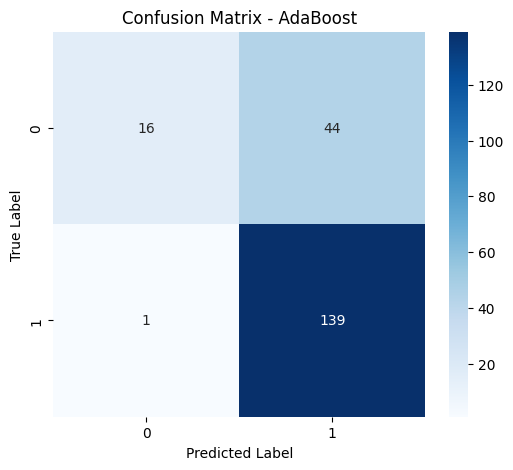

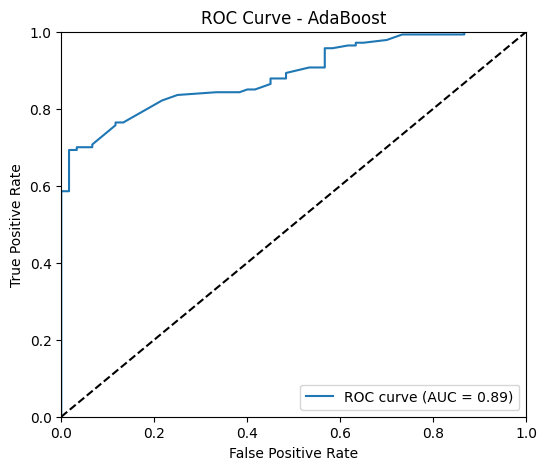

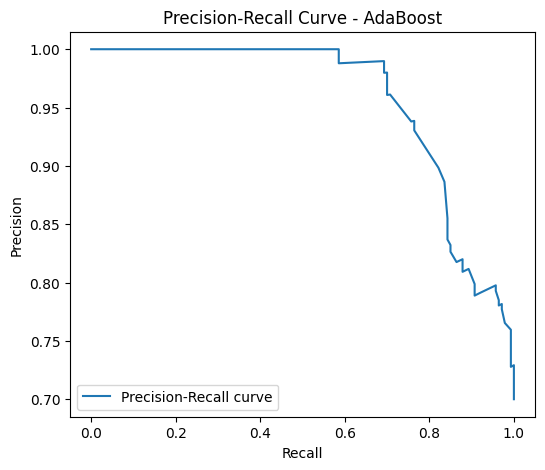

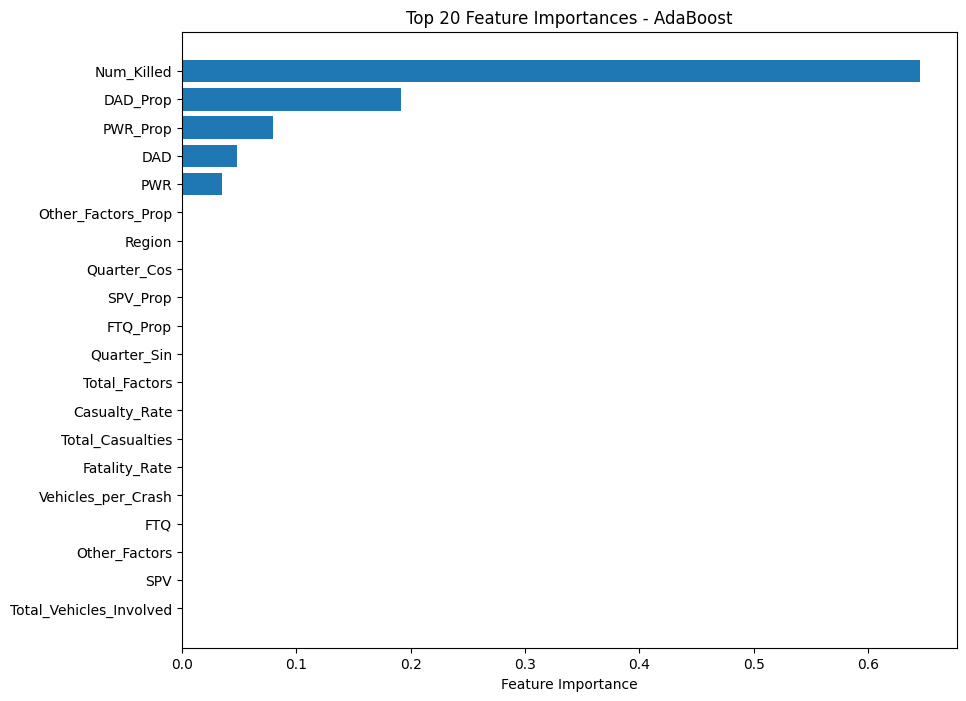

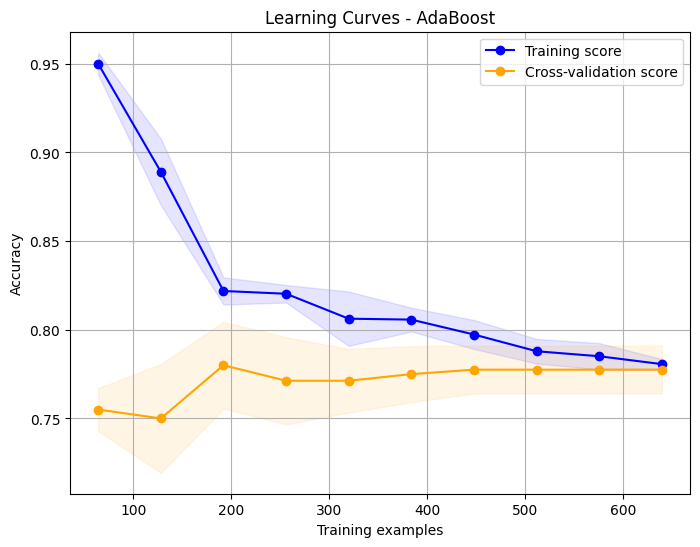

All graphs and results saved successfully.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')

drop_cols = [col for col in df.columns if col.startswith('State_') or col.startswith('Region_')]
drop_cols += ['State_Encoded', 'Region_Encoded', 'Quarter_Num', 'Year', 'Quarter_Date', 'High_Casualty']
df = df.drop(columns=drop_cols, errors='ignore')

categorical_cols = ['Quarter', 'State', 'Region']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop('Severe_Crash', axis=1)
y = df['Severe_Crash'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

base_estimator = DecisionTreeClassifier(max_depth=1, random_state=42)

param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
    'algorithm': ['SAMME', 'SAMME.R']
}

ada = AdaBoostClassifier(estimator=base_estimator, random_state=42)
random_search = RandomizedSearchCV(ada, param_dist, n_iter=30, cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=0)
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)
train_score = accuracy_score(y_train, train_pred)
test_score = accuracy_score(y_test, test_pred)
gap = train_score - test_score

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")
print(f"Train-Test Gap: {gap:.4f}")
print("\nBest Parameters:", random_search.best_params_)
print("\nClassification Report (Test):\n", classification_report(y_test, test_pred))

conf_mat = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - AdaBoost')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
plt.savefig('adaboost_confusion_matrix.png')
plt.close()

y_test_proba = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - AdaBoost')
plt.legend(loc='lower right')
plt.show()
plt.savefig('adaboost_roc_curve.png')
plt.close()

precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - AdaBoost')
plt.legend()
plt.show()
plt.savefig('adaboost_precision_recall.png')
plt.close()

feature_importance = best_model.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(feature_importance)[::-1]
plt.figure(figsize=(10,8))
plt.barh(range(len(sorted_idx[:20])), feature_importance[sorted_idx[:20]], align='center')
plt.yticks(range(len(sorted_idx[:20])), [feature_names[i] for i in sorted_idx[:20]])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances - AdaBoost')
plt.show()
plt.savefig('adaboost_feature_importance.png')
plt.close()

train_sizes, train_scores, test_scores = learning_curve(best_model, X_train, y_train, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy')
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
plt.figure(figsize=(8,6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-validation score')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.title('Learning Curves - AdaBoost')
plt.legend(loc='best')
plt.grid(True)
plt.show()
plt.savefig('adaboost_learning_curve.png')
plt.close()

results_df = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Train-Test Gap'],
    'Value': [train_score, test_score, gap]
})
results_df.to_csv('adaboost_model_scores.csv', index=False)
print("All graphs and results saved successfully.")